# PDF annotation

# Intro

After the pilot, we now annotate the unseen PDFs.

## packages and functions

In [ ]:
setwd(here::here("analysis_visualization"))
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

# Data

In [ ]:
results <- rio::import("2._annotation-results.csv")
abstracts_clean <- rio::import("https://github.com/JBGruber/opinion-wg2/raw/main/relevance-prediction/Opinion%20Papers%20Abstracts%20-%20data_abstracts_clean_withpredictedrelevance.csv") 

Total number of annotated papers:

In [ ]:
results |> 
  distinct(id) |> 
  nrow()

[1] 2615

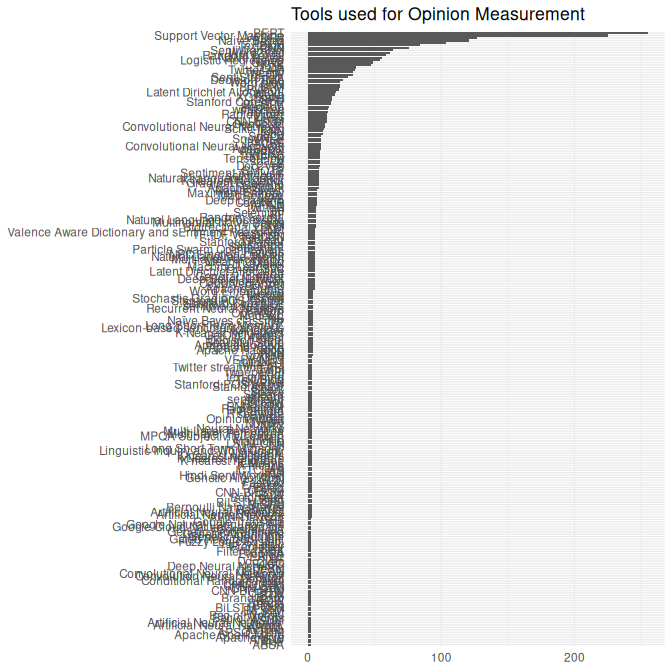

In [ ]:
tool_count <- results |> 
  filter(variable == "Q1_1_Tool-Name", !result %in% c("-", "IRRELEVANT")) |> 
  separate_longer_delim(cols = result, delim = "; ") |> 
  mutate(result = str_remove(result, "Classifier|Classifier|\\(.*\\)"),
         result = case_when(
           str_detect(result, "Naive.*Bay") ~ "Naive Bayes",
           str_detect(result, "BERT")  ~ "BERT",
           str_detect(result, "TextBlob")  ~ "TextBlob",
           str_detect(result, fixed("VADER", ignore_case = TRUE))  ~ "VADER",
           str_detect(result, fixed("Support Vector", ignore_case = TRUE)) | 
             str_detect(result, fixed("SVM", ignore_case = FALSE))  ~ "Support Vector Machine",
           str_detect(result, fixed("Glove", ignore_case = TRUE)) ~ "GloVe",
           TRUE ~ result
         )) |> 
  count(result) |> 
  mutate(tool = fct_reorder(result, n))

tool_count |> 
  slice_max(n, n = 250, with_ties = FALSE) |> 
  ggplot(aes(x = n, y = tool)) +
  geom_col() +
  labs(title = "Tools used for Opinion Measurement", x = NULL, y = NULL)

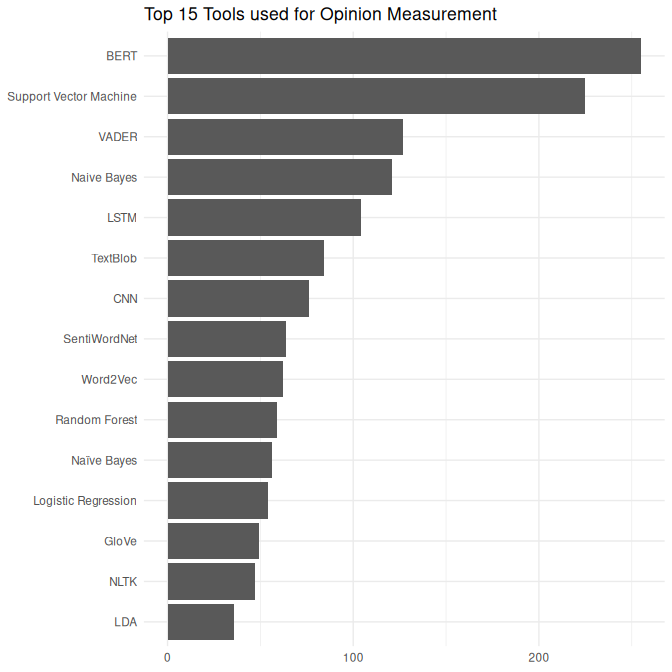

In [ ]:
tool_count |> 
  slice_max(n, n = 15) |> 
  ggplot(aes(x = n, y = tool)) +
  geom_col() +
  labs(title = "Top 15 Tools used for Opinion Measurement", x = NULL, y = NULL)

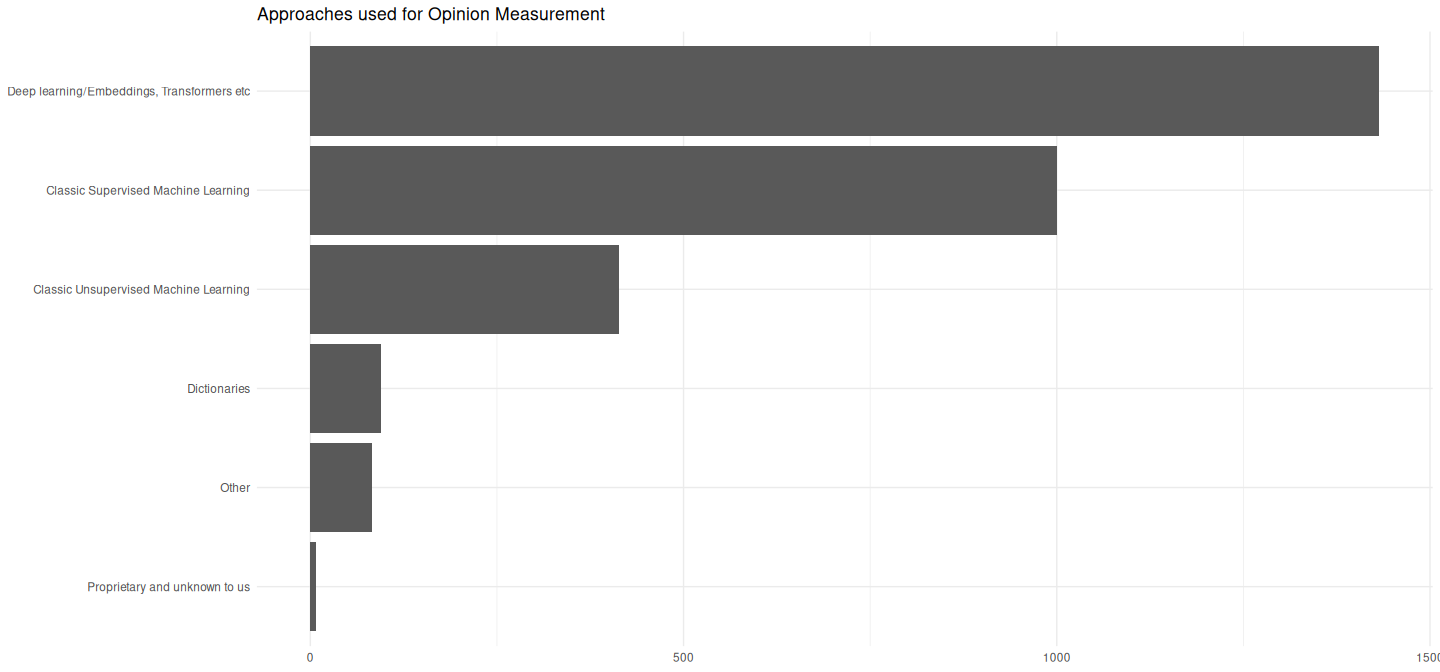

In [ ]:
approaches <- results |> 
  filter(variable == "Q3_1_Approach", !result %in% c("-", "IRRELEVANT")) |> 
  separate_longer_delim(cols = result, delim = ";") |> 
  mutate(result = trimws(result),
         result = case_when(
           str_detect(result, "Deep|Transformers|Embedding") ~ "Deep learning/Embeddings, Transformers etc",
           str_detect(result, "[U|u]nsupervised") ~ "Classic Unsupervised Machine Learning",
           str_detect(result, "\\b[S|s]upervised|[M|a]chine|Ensemble|Class") ~ "Classic Supervised Machine Learning",
           str_detect(result, "[D|d]ict|[L|l]exi") ~ "Dictionaries",
           str_detect(result, "Proprietary") ~ "Proprietary and unknown to us",
           
           TRUE ~ "Other"
         )) 

approaches |> 
  count(result) |> 
  mutate(approach = fct_reorder(result, n)) |> 
  ggplot(aes(x = n, y = approach)) +
  geom_col() +
  labs(title = "Approaches used for Opinion Measurement", x = NULL, y = NULL)

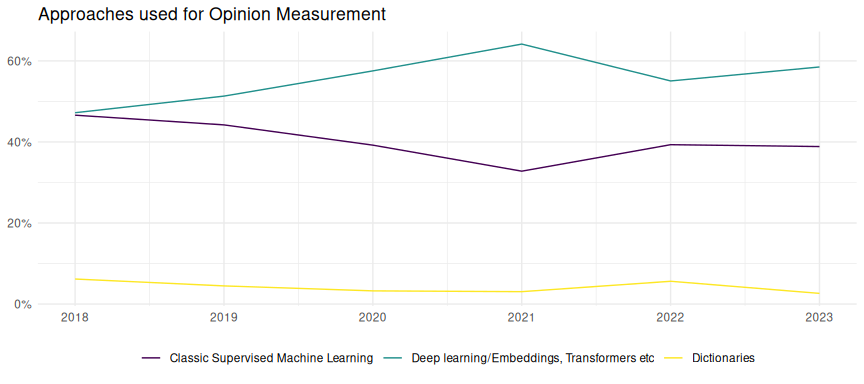

In [ ]:
approaches |>
  filter(result %in% c(
    "Classic Supervised Machine Learning",
    "Deep learning/Embeddings, Transformers etc",
    "Dictionaries"
  )) |> 
  left_join(abstracts_clean, by = "id") |> 
  count(result, year) |> 
  group_by(year) |> 
  mutate(pct = n / sum(n)) |> 
  ggplot(aes(x = year, y = pct, colour = result)) +
  geom_line() +
  scale_color_viridis_d() +
  scale_y_continuous(labels = scales::percent) +
  theme(legend.position = "bottom") +
  labs(title = "Approaches used for Opinion Measurement", 
       x = NULL, y = NULL, colour = NULL)

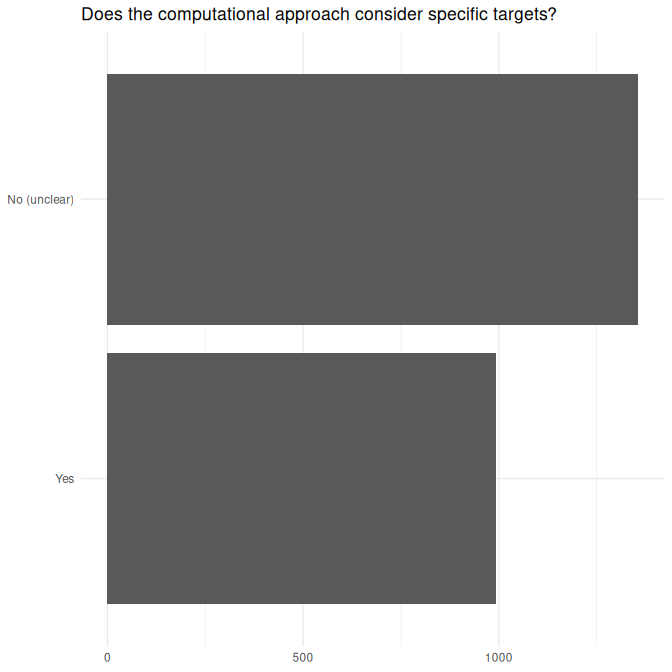

In [ ]:
results |> 
  filter(variable == "Q3_2_Target-specific-Measurement", !result %in% c("-", "IRRELEVANT")) |> 
  count(result) |> 
  mutate(result = fct_reorder(result, n)) |> 
  ggplot(aes(x = n, y = result)) +
  geom_col() +
  labs(title = "Does the computational approach consider specific targets?", x = NULL, y = NULL)

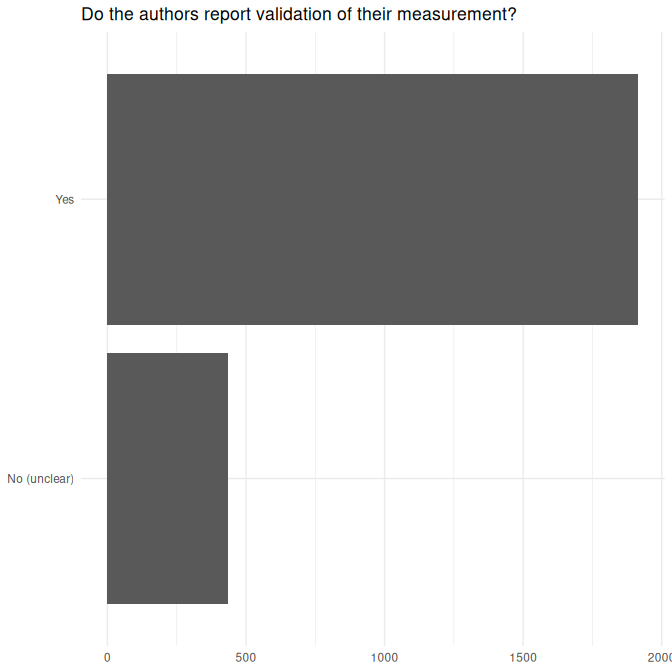

In [ ]:
results |> 
  filter(variable == "Q3_3_Validation", !result %in% c("-", "IRRELEVANT")) |> 
  count(result) |> 
  mutate(result = fct_reorder(result, n)) |> 
  ggplot(aes(x = n, y = result)) +
  geom_col() +
  labs(title = "Do the authors report validation of their measurement?", x = NULL, y = NULL)

# wrap up

Save data if it takes long to preprocess it here. Afterwards we get some
information which is important to reproduce the report.

In [ ]:
sessionInfo()

R version 4.5.0 (2025-04-11)
Platform: x86_64-pc-linux-gnu
Running under: EndeavourOS

Matrix products: default
BLAS:   /usr/lib/libblas.so.3.12.0 
LAPACK: /usr/lib/liblapack.so.3.12.0  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=de_DE.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=de_DE.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=de_DE.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=de_DE.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.4 forcats_1.0.0   stringr_1.5.1   dplyr_1.1.4    
 [5] purrr_1.0.4     readr_2.1.5     tidyr_1.3.1     tibble_3.2.1   
 [9] ggplot2_3.5.1   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonli

[1] "2025-05-26 11:42:29 CEST"

Time difference of 14.53026 secs